# Data Preprocessing Pipeline for PM2.5 Prediction Model

This notebook implements a comprehensive 7-phase preprocessing pipeline designed for machine learning model development:

**Phase 1:** Data Exploration & Profiling

**Phase 2:** Intelligent Missing Value Imputation

**Phase 3:** Feature Engineering (Temporal + Interaction Features)

**Phase 4:** Multi-Strategy Scaling (Group-Specific Approach)

**Phase 5:** Temporal Train/Val/Test Split (Prevents Data Leakage)

**Phase 6:** Correlation Analysis & Redundant Feature Removal

**Phase 7:** Quality Assurance & Overfitting Detection Setup

## Critical ML Principles Implemented:
- **Temporal Split:** Train/Val/Test split by date (not random) to respect causality
- **No Data Leakage:** Scalers and imputers fit ONLY on training data
- **Preserve Outliers:** Keep extreme values (important for air quality extremes)
- **Overfitting Detection:** Monitor train vs validation error gaps
- **TimeSeriesSplit:** For cross-validation during model training

## Setup: Import Libraries and Configure Paths

In [64]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# sklearn imports
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer

# Setup paths
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    base_dir = notebook_dir.parent
else:
    base_dir = notebook_dir

data_dir = base_dir / 'data'
output_dir = base_dir / 'preprocessed_data'
output_dir.mkdir(exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")

Base directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality
Data directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\data
Output directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\preprocessed_data


---
# PHASE 1: Data Exploration & Profiling

Load the merged dataset and explore its structure, missing values, and distributions.

In [65]:
# Load merged data
combined_file = data_dir / 'final_dataset.csv'
df = pd.read_csv(combined_file)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

Dataset shape: (41269, 20)

Column names and types:
date                     object
datetime_utc             object
id                        int64
latitude                float64
longitude               float64
temperature_celsius     float64
pressure_mb             float64
wind_u                  float64
wind_v                  float64
NO2                     float64
CO                      float64
O3                      float64
AOD                     float64
pm25                    float64
sensor_name              object
building_density          int64
road_density_km         float64
industrial_presence       int64
green_space_fraction      int64
relative_humidity       float64
dtype: object

First few rows:


,date,datetime_utc,id,latitude,longitude,temperature_celsius,pressure_mb,wind_u,wind_v,NO2,CO,O3,AOD,pm25,sensor_name,building_density,road_density_km,industrial_presence,green_space_fraction,relative_humidity
0,2016-11-25,2016-11-25 00:00:00,1,38.788056,-0.697222,6.493180,946.288660,0.230240,0.735303,NaN,NaN,NaN,0.1110,2.750000,ONTINYENT,88,94.835390,0,4,0.574378
1,2016-11-25,2016-11-25 00:00:00,36,39.945278,-0.056389,9.251236,993.626994,0.783218,-0.592618,NaN,NaN,NaN,0.0220,11.666667,ALMASSORA-C. P. OCHANDO,779,329.395812,5,467,0.234843
2,2016-11-30,2016-11-30 00:00:00,35,40.051944,-0.189722,10.044782,981.911432,-2.211047,-1.568971,NaN,NaN,NaN,0.2380,2.400000,ALCORA,22,171.888897,2,3,14.951133
3,2016-11-30,2016-11-30 00:00:00,37,40.062222,0.072778,12.299584,1008.794766,-3.236886,-2.804465,NaN,NaN,NaN,0.2480,2.600000,BENICASSIM,1275,294.935993,4,143,3.668484
4,2016-12-02,2016-12-02 00:00:00,1,38.788056,-0.697222,9.350630,953.114180,0.953454,0.293060,NaN,NaN,NaN,0.0755,2.750000,ONTINYENT,88,94.835390,0,4,7.820969


In [66]:

def display_feature_statistics(df):
    print("=" * 60)
    print(f"DATASET STATISTICS SUMMARY (Total Rows: {len(df)})")
    print("=" * 60)
    
    # Separate numerical columns from categorical/temporal columns
    num_cols = df.select_dtypes(include=[np.number]).columns
    
    print("\n--- NUMERICAL FEATURES ---")
    for col in num_cols:
        
        # Calculate statistics
        min_val = df[col].min()
        max_val = df[col].max()
        mean_val = df[col].mean()
        median_val = df[col].median()
        std_val = df[col].std()
        
        print(f"\n🔹 {col}:")
        print(f"   Range:   [{min_val:.4f}, {max_val:.4f}]")
        print(f"   Mean:    {mean_val:.4f} | Median: {median_val:.4f} | Std: {std_val:.4f}")

                
    print("\n" + "=" * 60)

display_feature_statistics(df)

DATASET STATISTICS SUMMARY (Total Rows: 41269)



--- NUMERICAL FEATURES ---

🔹 id:
   Range:   [0.0000, 109.0000]
   Mean:    52.2437 | Median: 46.0000 | Std: 35.0792

🔹 latitude:
   Range:   [36.1333, 43.5303]
   Mean:    39.0305 | Median: 39.4483 | Std: 2.2260

🔹 longitude:
   Range:   [-5.6635, 9.1364]
   Mean:    -0.4792 | Median: -0.4060 | Std: 3.8126

🔹 temperature_celsius:
   Range:   [-1.2791, 34.8658]
   Mean:    18.3794 | Median: 18.6451 | Std: 6.3801

🔹 pressure_mb:
   Range:   [930.3171, 1033.6622]
   Mean:    993.6838 | Median: 997.6124 | Std: 17.2482

🔹 wind_u:
   Range:   [-11.0987, 9.6617]
   Mean:    0.3307 | Median: 0.1864 | Std: 2.5284

🔹 wind_v:
   Range:   [-10.8600, 8.4864]
   Mean:    -0.1717 | Median: 0.0499 | Std: 1.3843

🔹 NO2:
   Range:   [0.0000, 0.0005]
   Mean:    0.0001 | Median: 0.0001 | Std: 0.0000

🔹 CO:
   Range:   [0.0131, 0.0976]
   Mean:    0.0316 | Median: 0.0314 | Std: 0.0039

🔹 O3:
   Range:   [0.1039, 0.2293]
   Mean:    0.1437 | Median: 0.1405 | Std: 0.0145

🔹 AOD:
   Range:   [0.0000, 5.47

Missing Values Summary:
Column  Missing_Count  Missing_Percent
    O3           2396             5.81
   NO2           2355             5.71
    CO           2355             5.71


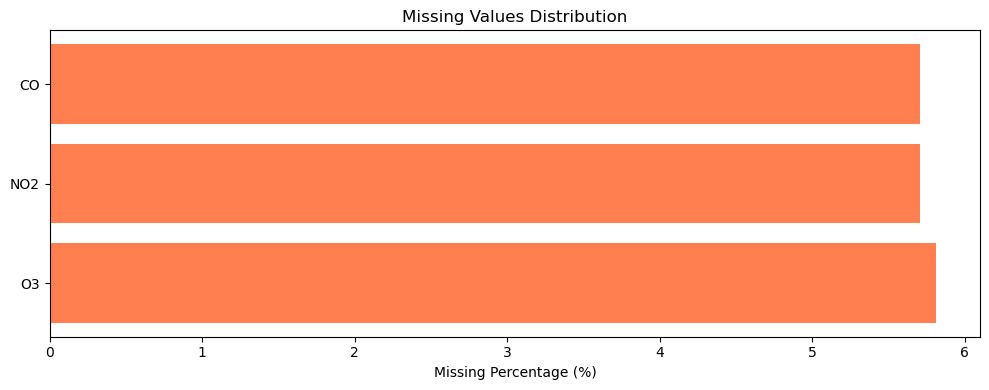


Total rows: 41269
Rows with complete data: 38873 (94.2%)


In [67]:
# Missing values overview
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Percent', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 4))
missing_data = missing_df[missing_df['Missing_Count'] > 0]
ax.barh(missing_data['Column'], missing_data['Missing_Percent'], color='coral')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values Distribution')
plt.tight_layout()
plt.show()

print(f"\nTotal rows: {len(df)}")
print(f"Rows with complete data: {len(df.dropna())} ({len(df.dropna())/len(df)*100:.1f}%)")

In [68]:
# Identify feature categories
print("Feature Categorization:")
print("\n1. TEMPORAL FEATURES:")
print("  - date, datetime_utc")

print("\n2. GEOGRAPHIC FEATURES:")
print("  - latitude, longitude, id, sensor_name")

print("\n3. METEOROLOGICAL FEATURES:")
meteorological = ['temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v', 'relative_humidity']
for col in meteorological:
    print(f"  - {col}: {df[col].isnull().sum()} missing")

print("\n4. ATMOSPHERIC POLLUTION FEATURES (with missing values):")
pollution = ['NO2', 'CO', 'O3', 'AOD']
for col in pollution:
    print(f"  - {col}: {df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.2f}%)")

print("\n5. LAND USE / SPATIAL FEATURES:")
land_use = ['building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction']
for col in land_use:
    print(f"  - {col}: {df[col].isnull().sum()} missing")

print("\n6. TARGET VARIABLE:")
print(f"  - pm25: {df['pm25'].isnull().sum()} missing")
print(f"    Range: [{df['pm25'].min():.2f}, {df['pm25'].max():.2f}]")

Feature Categorization:

1. TEMPORAL FEATURES:
  - date, datetime_utc

2. GEOGRAPHIC FEATURES:
  - latitude, longitude, id, sensor_name

3. METEOROLOGICAL FEATURES:
  - temperature_celsius: 0 missing
  - pressure_mb: 0 missing
  - wind_u: 0 missing
  - wind_v: 0 missing
  - relative_humidity: 0 missing

4. ATMOSPHERIC POLLUTION FEATURES (with missing values):
  - NO2: 2355 missing (5.71%)
  - CO: 2355 missing (5.71%)
  - O3: 2396 missing (5.81%)
  - AOD: 0 missing (0.00%)

5. LAND USE / SPATIAL FEATURES:
  - building_density: 0 missing
  - road_density_km: 0 missing
  - industrial_presence: 0 missing
  - green_space_fraction: 0 missing

6. TARGET VARIABLE:
  - pm25: 0 missing
    Range: [-999.00, 1000.00]


In [69]:
# Check for -999 or invalid values in pm25
print("PM25 value distribution:")
print(f"  Min: {df['pm25'].min()}")
print(f"  Max: {df['pm25'].max()}")
print(f"  Mean: {df['pm25'].mean():.2f}")
print(f"  Median: {df['pm25'].median():.2f}")

# Check for -999 as missing value marker
invalid_pm25 = (df['pm25'] < 0).sum()
print(f"\nNegative PM25 values (likely invalid): {invalid_pm25}")
if invalid_pm25 > 0:
    print(f"  These should be treated as missing values")

PM25 value distribution:
  Min: -999.0
  Max: 1000.0
  Mean: 9.09
  Median: 7.75

Negative PM25 values (likely invalid): 273
  These should be treated as missing values


---
# PHASE 2: Intelligent Missing Value Imputation

Implement context-specific imputation strategies:
- **KNN Imputation** for meteorological features (complete data)
- **Forward-Fill + Linear Interpolation** for pollution features (temporal property)
- **Preserve invalid values** in target for later filtering

In [70]:
# Create working copy
df_clean = df.copy()

# Convert date to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

print(f"Original shape: {df_clean.shape}")
print(f"Missing values before imputation:")
print(df_clean[['NO2', 'CO', 'O3', 'AOD', 'pm25']].isnull().sum())

Original shape: (41269, 20)
Missing values before imputation:
NO2     2355
CO      2355
O3      2396
AOD        0
pm25       0
dtype: int64


In [71]:
# Step 1: Handle PM25 invalid values (-999 or negative)
df_clean['pm25_valid'] = df_clean['pm25'] >= 0
invalid_pm25_count = (~df_clean['pm25_valid']).sum()
print(f"PM25 invalid values marked: {invalid_pm25_count}")
print(f"  Will filter these out before training (not during preprocessing)")

# Step 2: Impute meteorological features using KNN
meteorological_features = ['temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v']
print(f"\nMeteorological features (all complete): {df_clean[meteorological_features].isnull().sum().sum()} missing")

PM25 invalid values marked: 273
  Will filter these out before training (not during preprocessing)

Meteorological features (all complete): 0 missing


In [72]:
# Step 3: Mark pollution features for post-split imputation
# Strategy: Do NOT impute before splitting to avoid any potential data leakage
# Missing values will be imputed AFTER split using spatial + temporal strategy
pollution_features = ['NO2', 'CO', 'O3', 'AOD']

print("Pollution features will be imputed AFTER train/val/test split using spatial KNN + forward-fill...")
for col in pollution_features:
    missing_count = df_clean[col].isnull().sum()
    print(f"  {col}: {missing_count} missing values")
print("\nImputation strategy (post-split):")
print("  1. Spatial KNN: Use nearest geographic neighbors (realistic for real-time)")
print("  2. Forward-fill: Use previous value at same location (temporal continuity)")
print("  3. Train median: Final fallback for remaining missing values")


Pollution features will be imputed AFTER train/val/test split using spatial KNN + forward-fill...
  NO2: 2355 missing values
  CO: 2355 missing values
  O3: 2396 missing values
  AOD: 0 missing values

Imputation strategy (post-split):
  1. Spatial KNN: Use nearest geographic neighbors (realistic for real-time)
  2. Forward-fill: Use previous value at same location (temporal continuity)
  3. Train median: Final fallback for remaining missing values


---
# PHASE 3: Feature Engineering (Temporal + Interaction Features)

Create temporal patterns and interaction features that capture domain-specific relationships.

In [73]:
# Temporal Features
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day'] = df_clean['date'].dt.day
df_clean['dayofweek'] = df_clean['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['dayofyear'] = df_clean['date'].dt.dayofyear
df_clean['quarter'] = df_clean['date'].dt.quarter
df_clean['week'] = df_clean['date'].dt.isocalendar().week

# Cyclical encoding for month (capture seasonal circularity)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['month'] / 12)

# Cyclical encoding for day of week
df_clean['dow_sin'] = np.sin(2 * np.pi * df_clean['dayofweek'] / 7)
df_clean['dow_cos'] = np.cos(2 * np.pi * df_clean['dayofweek'] / 7)

print("Temporal features created:")
temporal_features = ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter', 'week', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
for f in temporal_features:
    print(f"  - {f}")

Temporal features created:
  - year
  - month
  - day
  - dayofweek
  - dayofyear
  - quarter
  - week
  - month_sin
  - month_cos
  - dow_sin
  - dow_cos


In [74]:
# Interaction Features
print("\nCreating interaction features...")

# Wind magnitude and direction
df_clean['wind_magnitude'] = np.sqrt(df_clean['wind_u']**2 + df_clean['wind_v']**2)
df_clean['wind_direction'] = np.arctan2(df_clean['wind_v'], df_clean['wind_u'])

# Temperature-Pressure interaction (thermodynamic stability)
df_clean['temp_pressure_interaction'] = df_clean['temperature_celsius'] * (df_clean['pressure_mb'] / 1000)

# Lagged features (previous day average for each location)
df_clean['pm25_lag1'] = (
    df_clean.groupby(['latitude', 'longitude'])['pm25'].shift(1)
).where(
    df_clean.groupby(['latitude', 'longitude'])['pm25_valid'].shift(1) == True, 
    np.nan
)

interaction_features = [
    'wind_magnitude', 'wind_direction', 'temp_pressure_interaction','pm25_lag1']
for f in interaction_features:
    print(f"  - {f}")

print(f"\nNew dataset shape: {df_clean.shape}")
print(f"Missing values in lag feature: {df_clean[['pm25_lag1']].isnull().sum()}")



Creating interaction features...


  - wind_magnitude
  - wind_direction
  - temp_pressure_interaction
  - pm25_lag1

New dataset shape: (41269, 36)
Missing values in lag feature: pm25_lag1    371
dtype: int64


``Note`` : more interaction features related to polution would be created after data splitting and after polution missing values imputation

In [75]:
# Remove rows with invalid PM25 or lagged values at start
df_model = df_clean[df_clean['pm25_valid']].copy()

print(f"Dataset size after cleaning: {len(df_model)} (from {len(df_clean)})")
print(f"Rows removed: {len(df_clean) - len(df_model)}")

# Sort by date to ensure temporal order
df_model = df_model.sort_values('date').reset_index(drop=True)
print(f"\nDate range: {df_model['date'].min()} to {df_model['date'].max()}")
print(f"Days covered: {(df_model['date'].max() - df_model['date'].min()).days}")

Dataset size after cleaning: 40996 (from 41269)
Rows removed: 273

Date range: 2016-11-25 00:00:00 to 2026-04-06 00:00:00
Days covered: 3419


In [76]:
# Temporal split: 70% train, 10% val, 20% test

# Get unique sorted dates
unique_dates = sorted(df_model['date'].unique())
n_dates = len(unique_dates)

# Calculate date split points
train_date_cutoff = int(0.70 * n_dates)
val_date_cutoff = int(0.80 * n_dates)

train_dates = unique_dates[:train_date_cutoff]
val_dates = unique_dates[train_date_cutoff:val_date_cutoff]
test_dates = unique_dates[val_date_cutoff:]

# Create splits based on dates
df_train = df_model[df_model['date'].isin(train_dates)].copy()
df_val = df_model[df_model['date'].isin(val_dates)].copy()
df_test = df_model[df_model['date'].isin(test_dates)].copy()

print("Temporal Train/Val/Test Split (Date-Based):")
print(f"\nTRAIN: {len(df_train)} rows ({len(df_train)/len(df_model)*100:.1f}%) across {len(train_dates)} dates")
print(f"  Date range: {df_train['date'].min()} to {df_train['date'].max()}")

print(f"\nVALIDATION: {len(df_val)} rows ({len(df_val)/len(df_model)*100:.1f}%) across {len(val_dates)} dates")
print(f"  Date range: {df_val['date'].min()} to {df_val['date'].max()}")

print(f"\nTEST: {len(df_test)} rows ({len(df_test)/len(df_model)*100:.1f}%) across {len(test_dates)} dates")
print(f"  Date range: {df_test['date'].min()} to {df_test['date'].max()}")

# Verify no date overlap
assert len(set(train_dates) & set(val_dates)) == 0, "Date overlap between train and val!"
assert len(set(train_dates) & set(test_dates)) == 0, "Date overlap between train and test!"
assert len(set(val_dates) & set(test_dates)) == 0, "Date overlap between val and test!"

print(f"\n✓ Temporal ordering preserved (no leakage possible)")
print(f"  Train ends before Val, Val ends before Test")
print(f"✓ No date overlap between splits verified")


Temporal Train/Val/Test Split (Date-Based):

TRAIN: 24543 rows (59.9%) across 1593 dates
  Date range: 2016-11-25 00:00:00 to 2024-04-21 00:00:00

VALIDATION: 6188 rows (15.1%) across 227 dates
  Date range: 2024-04-22 00:00:00 to 2024-12-06 00:00:00

TEST: 10265 rows (25.0%) across 456 dates
  Date range: 2024-12-07 00:00:00 to 2026-04-06 00:00:00

✓ Temporal ordering preserved (no leakage possible)
  Train ends before Val, Val ends before Test
✓ No date overlap between splits verified


In [77]:
# ============================================================================
# REALISTIC IMPUTATION STRATEGY FOR DEPLOYMENT (NO DATA LEAKAGE)
# ============================================================================
print(f"\n{'='*80}")
print("IMPUTING POLLUTION FEATURES: SPATIO-TEMPORAL KNN → FORWARD-FILL → TRAIN MEDIAN")
print(f"{'='*80}")

from sklearn.impute import KNNImputer

pollution_features = ['NO2', 'CO', 'O3', 'AOD']

# Store train medians for final fallback
train_medians = {}

# ========================================================================
# SETUP: Create Time Penalty Feature for Spatio-Temporal KNN
# ========================================================================
# TIME_WEIGHT = 0.035 creates a tipping point around 14 days vs 50km neighbor distance
TIME_WEIGHT = 0.035

base_date = df_train['date'].min()
df_train['time_penalty'] = (df_train['date'] - base_date).dt.days * TIME_WEIGHT
df_val['time_penalty'] = (df_val['date'] - base_date).dt.days * TIME_WEIGHT
df_test['time_penalty'] = (df_test['date'] - base_date).dt.days * TIME_WEIGHT

for col in pollution_features:
    print(f"\n{'='*60}")
    print(f"Imputing {col}")
    print(f"{'='*60}")
    
    # Track missing counts
    train_missing_initial = df_train[col].isnull().sum()
    val_missing_initial = df_val[col].isnull().sum()
    test_missing_initial = df_test[col].isnull().sum()
    
    print(f"Initial missing: Train={train_missing_initial}, Val={val_missing_initial}, Test={test_missing_initial}")
    
    # ========================================================================
    # STEP 1: Spatio-Temporal KNN Imputation (using geographic neighbors & time)
    # ========================================================================
    print(f"\nStep 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...")
    
    knn_features = ['latitude', 'longitude', 'time_penalty', col]
    
    # Fit KNN on training data only
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    knn_imputer.fit(df_train[knn_features].values)
    
    # Apply to all splits (col is at index 3 in our knn_features array)
    df_train[col] = knn_imputer.transform(df_train[knn_features].values)[:, 3]
    df_val[col] = knn_imputer.transform(df_val[knn_features].values)[:, 3]
    df_test[col] = knn_imputer.transform(df_test[knn_features].values)[:, 3]
    
    train_after_knn = df_train[col].isnull().sum()
    val_after_knn = df_val[col].isnull().sum()
    test_after_knn = df_test[col].isnull().sum()
    
    print(f"  After KNN: Train={train_after_knn}, Val={val_after_knn}, Test={test_after_knn}")
    
    # ========================================================================
    # STEP 2: Forward-fill within location groups (temporal continuity)
    # ========================================================================
    if train_after_knn > 0 or val_after_knn > 0 or test_after_knn > 0:
        print(f"\nStep 2: Forward-fill within location groups...")
        
        df_train[col] = df_train.groupby(['latitude', 'longitude'])[col].ffill()
        df_val[col] = df_val.groupby(['latitude', 'longitude'])[col].ffill()
        df_test[col] = df_test.groupby(['latitude', 'longitude'])[col].ffill()
        
        train_after_ffill = df_train[col].isnull().sum()
        val_after_ffill = df_val[col].isnull().sum()
        test_after_ffill = df_test[col].isnull().sum()
        
        print(f"  After ffill: Train={train_after_ffill}, Val={val_after_ffill}, Test={test_after_ffill}")
    
    # ========================================================================
    # STEP 3: Train median fallback (for any remaining missing values)
    # ========================================================================
    if df_train[col].isnull().sum() > 0 or df_val[col].isnull().sum() > 0 or df_test[col].isnull().sum() > 0:
        print(f"\nStep 3: Train median fallback...")
        
        train_medians[col] = df_train[col].median()
        
        df_train[col] = df_train[col].fillna(train_medians[col])
        df_val[col] = df_val[col].fillna(train_medians[col])
        df_test[col] = df_test[col].fillna(train_medians[col])
        
        print(f"  Train median = {train_medians[col]:.4f}")
    
    # Final check
    train_final = df_train[col].isnull().sum()
    val_final = df_val[col].isnull().sum()
    test_final = df_test[col].isnull().sum()
    
    print(f"\n✓ Final: Train={train_final}, Val={val_final}, Test={test_final}")
    print(f"✓ {col} fully imputed: {train_missing_initial + val_missing_initial + test_missing_initial} total missing → 0")

print(f"\n{'='*80}")
print(" ALL IMPUTATION COMPLETE ")
print(f"{'='*80}")
print("Strategy used:")
print("Pollution features: Spatio-Temporal KNN (k=5) → Forward-fill → Train median")



IMPUTING POLLUTION FEATURES: SPATIO-TEMPORAL KNN → FORWARD-FILL → TRAIN MEDIAN

Imputing NO2
Initial missing: Train=2355, Val=0, Test=0

Step 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...
  After KNN: Train=0, Val=0, Test=0

✓ Final: Train=0, Val=0, Test=0
✓ NO2 fully imputed: 2355 total missing → 0

Imputing CO
Initial missing: Train=2355, Val=0, Test=0

Step 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...
  After KNN: Train=0, Val=0, Test=0

✓ Final: Train=0, Val=0, Test=0
✓ CO fully imputed: 2355 total missing → 0

Imputing O3
Initial missing: Train=2396, Val=0, Test=0

Step 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...
  After KNN: Train=0, Val=0, Test=0

✓ Final: Train=0, Val=0, Test=0
✓ O3 fully imputed: 2396 total missing → 0

Imputing AOD
Initial missing: Train=0, Val=0, Test=0

Step 1: Spatio-Temporal KNN imputation (k=5 nearest neighbors)...
  After KNN: Train=0, Val=0, Test=0

✓ Final: Train=0, Val=0, Test=0
✓ AOD fully imputed: 0 

## Creating more interaction features

In [78]:
def create_pollution_features(df):
    """
    Calculates pollution-based interactions and lagged features.
    Designed to be run on dataset splits AFTER imputation to prevent data leakage.
    """
    df_out = df.copy() # Prevent SettingWithCopy warnings
    
    # Atmospheric pollution index
    df_out['pollution_index'] = (df_out['NO2'] + df_out['CO'] + df_out['O3']) / 3

    # Aerosol-Pollution interaction
    df_out['aod_pollution_interaction'] = df_out['AOD'] * df_out['pollution_index']

    # Temperature effects on pollutant dispersion
    df_out['temp_pollution_interaction'] = df_out['temperature_celsius'] * df_out['pollution_index']

    # Pressure effect on dispersion (higher pressure = lower dispersion)
    df_out['pressure_pollution_interaction'] = (1033 - df_out['pressure_mb']) * df_out['pollution_index']
    
    # Lagged features (ensure your df is temporally sorted before calling this)
    df_out['temp_lag1'] = df_out.groupby(['latitude', 'longitude'])['temperature_celsius'].shift(1)
    df_out['pollution_lag1'] = df_out.groupby(['latitude', 'longitude'])['pollution_index'].shift(1)
    
    return df_out



In [79]:
df_train = create_pollution_features(df_train)
df_val = create_pollution_features(df_val)
df_test = create_pollution_features(df_test)

- checking for missing values

In [80]:
# List of the newly created features
new_features = [
    'pollution_index', 
    'aod_pollution_interaction', 
    'temp_pollution_interaction', 
    'pressure_pollution_interaction', 
    'temp_lag1', 
    'pollution_lag1'
]

# Check for missing values in each split
for name, df in zip(['Train', 'Validation', 'Test'], [df_train, df_val, df_test]):
    print(f"--- Missing values in {name} ---")
    # We only check the new_features columns
    missing_counts = df[new_features].isna().sum()
    print(missing_counts)
    print()


--- Missing values in Train ---
pollution_index                    0
aod_pollution_interaction          0
temp_pollution_interaction         0
pressure_pollution_interaction     0
temp_lag1                         68
pollution_lag1                    68
dtype: int64

--- Missing values in Validation ---
pollution_index                    0
aod_pollution_interaction          0
temp_pollution_interaction         0
pressure_pollution_interaction     0
temp_lag1                         50
pollution_lag1                    50
dtype: int64

--- Missing values in Test ---
pollution_index                    0
aod_pollution_interaction          0
temp_pollution_interaction         0
pressure_pollution_interaction     0
temp_lag1                         66
pollution_lag1                    66
dtype: int64



- imputing the missing values in the newly added features along with the pm25_lag1 that was created before splitting

In [81]:

print(f"\n{'='*80}")
print("IMPUTING LAGS FEATURES WITH TRAIN MEDIANS")
print(f"{'='*80}")

lag_features = ['pm25_lag1', 'temp_lag1', 'pollution_lag1']


for col in lag_features:
    train_missing = df_train[col].isnull().sum()
    val_missing = df_val[col].isnull().sum()
    test_missing = df_test[col].isnull().sum()
    
    if train_missing > 0 or val_missing > 0 or test_missing > 0:
        train_medians[col] = df_train[col].median()
        
        df_train[col].fillna(train_medians[col], inplace=True)
        df_val[col].fillna(train_medians[col], inplace=True)
        df_test[col].fillna(train_medians[col], inplace=True)
        
        print(f"\n{col}: train median = {train_medians[col]:.4f}")
        print(f"  Train: {train_missing} → 0 | Val: {val_missing} → 0 | Test: {test_missing} → 0")



IMPUTING LAGS FEATURES WITH TRAIN MEDIANS

pm25_lag1: train median = 7.4744
  Train: 101 → 0 | Val: 32 → 0 | Test: 22 → 0

temp_lag1: train median = 18.2395
  Train: 68 → 0 | Val: 50 → 0 | Test: 66 → 0

pollution_lag1: train median = 0.0562
  Train: 68 → 0 | Val: 50 → 0 | Test: 66 → 0


---
# PHASE 4: Multi-Strategy Scaling (Group-Specific Approach)

In [82]:
# Define feature groups for scaling
geographic_features = ['latitude', 'longitude']
meteorological_features = ['temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v','relative_humidity']
pollution_features = ['NO2', 'CO', 'O3', 'AOD']
polution_interaction_features = [
    'pollution_index',
    'aod_pollution_interaction',
    'temp_pollution_interaction',
    'pressure_pollution_interaction',
    'temp_lag1',
    'pollution_lag1'
]
land_use_features = ['building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction']

engineered_features = temporal_features + interaction_features + polution_interaction_features
target_feature = ['pm25']

all_features = (geographic_features + meteorological_features + pollution_features + 
                engineered_features + land_use_features)

print(f"Total features for scaling: {len(all_features)}")
print(f"  - Geographic: {len(geographic_features)}")
print(f"  - Meteorological: {len(meteorological_features)}")
print(f"  - Pollution: {len(pollution_features)}")
print(f"  - Land use: {len(land_use_features)}")
print(f"  - Engineered: {len(engineered_features)}")

Total features for scaling: 36
  - Geographic: 2
  - Meteorological: 5
  - Pollution: 4
  - Land use: 4
  - Engineered: 21


In [85]:
# Create scaling dictionary
scaling_config = {
    'standard': [
        'temperature_celsius', 'wind_u', 'wind_v', 'wind_magnitude'
    ],
    'robust': [
        'pressure_mb', 'NO2', 'CO', 'O3', 'AOD', 
        'building_density', 'road_density_km', 'industrial_presence', 
        'green_space_fraction', 'relative_humidity',
        'pollution_index', 'aod_pollution_interaction', 
        'temp_pollution_interaction', 'pressure_pollution_interaction'
        ,'temp_pressure_interaction',
        'pm25_lag1', 'temp_lag1', 'pollution_lag1'
    ],
    'no_scale': [
        'latitude', 'longitude', 'year', 'month', 'day', 'dayofweek', 
        'dayofyear', 'quarter', 'week', 'month_sin', 'month_cos', 
        'dow_sin', 'dow_cos', 'wind_direction',
        # 'temp_pressure_interaction',
        # 'pm25_lag1', 'temp_lag1', 'pollution_lag1'
    ]
}

all_scaling_features = (scaling_config['standard'] + scaling_config['robust'] + 
                        scaling_config['no_scale'])

print(f"Total features configured for scaling: {len(all_scaling_features)}")
print(f"Features to scale: {len(scaling_config['standard']) + len(scaling_config['robust'])}")
print(f"Features to preserve: {len(scaling_config['no_scale'])}")

# Store configuration
scaling_config_info = {
    'standard_scaler_features': scaling_config['standard'],
    'robust_scaler_features': scaling_config['robust'],
    'no_scale_features': scaling_config['no_scale']
}


Total features configured for scaling: 36
Features to scale: 22
Features to preserve: 14


Note : The RobustScaler scales data using the median and interquartile range (IQR) instead of mean and standard deviation, making it resistant to outliers.


In [86]:
# Fit scalers on TRAINING DATA ONLY
print("Fitting scalers on training data only...\n")

# Initialize scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit on training data
df_train[scaling_config['standard']] = standard_scaler.fit_transform(
    df_train[scaling_config['standard']]
)
df_train[scaling_config['robust']] = robust_scaler.fit_transform(
    df_train[scaling_config['robust']]
)

print(f"✓ StandardScaler fit on {len(df_train)} training samples")
print(f"  Features: {scaling_config['standard']}")
print(f"\n✓ RobustScaler fit on {len(df_train)} training samples")
print(f"  Features: {scaling_config['robust']}")

Fitting scalers on training data only...

✓ StandardScaler fit on 24543 training samples
  Features: ['temperature_celsius', 'wind_u', 'wind_v', 'wind_magnitude']

✓ RobustScaler fit on 24543 training samples
  Features: ['pressure_mb', 'NO2', 'CO', 'O3', 'AOD', 'building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction', 'relative_humidity', 'pollution_index', 'aod_pollution_interaction', 'temp_pollution_interaction', 'pressure_pollution_interaction', 'temp_pressure_interaction', 'pm25_lag1', 'temp_lag1', 'pollution_lag1']


In [87]:
# Apply fitted scalers to VALIDATION and TEST data
print("Applying fitted scalers to validation and test data...")

df_val[scaling_config['standard']] = standard_scaler.transform(
    df_val[scaling_config['standard']]
)
df_val[scaling_config['robust']] = robust_scaler.transform(
    df_val[scaling_config['robust']]
)

df_test[scaling_config['standard']] = standard_scaler.transform(
    df_test[scaling_config['standard']]
)
df_test[scaling_config['robust']] = robust_scaler.transform(
    df_test[scaling_config['robust']]
)

print(f"✓ Validation set ({len(df_val)} rows) transformed with training scalers")
print(f"✓ Test set ({len(df_test)} rows) transformed with training scalers")
print(f"\n✓ NO DATA LEAKAGE: Scalers fit ONLY on training data")

Applying fitted scalers to validation and test data...
✓ Validation set (6188 rows) transformed with training scalers
✓ Test set (10265 rows) transformed with training scalers

✓ NO DATA LEAKAGE: Scalers fit ONLY on training data


In [88]:
# Setup for TimeSeriesSplit cross-validation
print("TimeSeriesSplit Setup for Model Training:")
timeseries_split = TimeSeriesSplit(n_splits=5)

print(f"Number of CV folds: {timeseries_split.get_n_splits()}")
print(f"\nFold structure (each fold splits train data temporally):")

for fold_idx, (train_idx, val_idx) in enumerate(timeseries_split.split(df_train), 1):
    fold_train = df_train.iloc[train_idx]
    fold_val = df_train.iloc[val_idx]
    print(f"\n  Fold {fold_idx}:")
    print(f"    Train: {len(train_idx)} samples ({fold_train['date'].min()} to {fold_train['date'].max()})")
    print(f"    Val:   {len(val_idx)} samples ({fold_val['date'].min()} to {fold_val['date'].max()})")

TimeSeriesSplit Setup for Model Training:
Number of CV folds: 5

Fold structure (each fold splits train data temporally):

  Fold 1:
    Train: 4093 samples (2016-11-25 00:00:00 to 2019-07-29 00:00:00)


    Val:   4090 samples (2019-07-29 00:00:00 to 2021-02-18 00:00:00)

  Fold 2:
    Train: 8183 samples (2016-11-25 00:00:00 to 2021-02-18 00:00:00)
    Val:   4090 samples (2021-02-18 00:00:00 to 2021-12-15 00:00:00)

  Fold 3:
    Train: 12273 samples (2016-11-25 00:00:00 to 2021-12-15 00:00:00)
    Val:   4090 samples (2021-12-16 00:00:00 to 2022-08-26 00:00:00)

  Fold 4:
    Train: 16363 samples (2016-11-25 00:00:00 to 2022-08-26 00:00:00)
    Val:   4090 samples (2022-08-26 00:00:00 to 2023-08-30 00:00:00)

  Fold 5:
    Train: 20453 samples (2016-11-25 00:00:00 to 2023-08-30 00:00:00)
    Val:   4090 samples (2023-08-30 00:00:00 to 2024-04-21 00:00:00)


In [89]:
# Prepare feature sets for modeling
feature_cols = (scaling_config['standard'] + scaling_config['robust'] + 
                scaling_config['no_scale'])
target_col = 'pm25'

X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[target_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[target_col].copy()

print("Feature Sets Prepared:")
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nX_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"\nX_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Feature Sets Prepared:

X_train shape: (24543, 36)
y_train shape: (24543,)

X_val shape: (6188, 36)
y_val shape: (6188,)

X_test shape: (10265, 36)
y_test shape: (10265,)


In [90]:
# Save scaled datasets
print("Saving preprocessed datasets...")

df_train.to_csv(output_dir / 'train_preprocessed.csv', index=False)
df_val.to_csv(output_dir / 'val_preprocessed.csv', index=False)
df_test.to_csv(output_dir / 'test_preprocessed.csv', index=False)

X_train.to_csv(output_dir / 'X_train.csv', index=False)
y_train.to_csv(output_dir / 'y_train.csv', index=False, header=True)
X_val.to_csv(output_dir / 'X_val.csv', index=False)
y_val.to_csv(output_dir / 'y_val.csv', index=False, header=True)
X_test.to_csv(output_dir / 'X_test.csv', index=False)
y_test.to_csv(output_dir / 'y_test.csv', index=False, header=True)

print(f"✓ Saved to {output_dir}")
print(f"  - train_preprocessed.csv ({len(df_train)} rows)")
print(f"  - val_preprocessed.csv ({len(df_val)} rows)")
print(f"  - test_preprocessed.csv ({len(df_test)} rows)")

Saving preprocessed datasets...
✓ Saved to c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\preprocessed_data
  - train_preprocessed.csv (24543 rows)
  - val_preprocessed.csv (6188 rows)
  - test_preprocessed.csv (10265 rows)


In [91]:
# Save scaler objects for later use
import joblib

joblib.dump(standard_scaler, output_dir / 'standard_scaler.pkl')
joblib.dump(robust_scaler, output_dir / 'robust_scaler.pkl')
joblib.dump(scaling_config_info, output_dir / 'scaling_config.pkl')

print("\n✓ Saved scaler objects for inference pipeline")
print("  - standard_scaler.pkl")
print("  - robust_scaler.pkl")
print("  - scaling_config.pkl")
print(f"\nAll preprocessed data and scalers saved to: {output_dir}")


✓ Saved scaler objects for inference pipeline
  - standard_scaler.pkl
  - robust_scaler.pkl
  - scaling_config.pkl

All preprocessed data and scalers saved to: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\preprocessed_data


---
# PHASE 6: Correlation Analysis & Redundant Feature Removal

In [92]:
# Analyze feature correlations using training data (include target)
print("Feature Correlation Analysis (using training data only):\n")

# Create a dataframe with features and target for correlation
X_train_with_target = X_train.copy()
X_train_with_target['pm25'] = y_train

correlation_matrix = X_train_with_target.corr()

# Find highly correlated features (redundancy detection)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)-1):  # Exclude target when looking for feature redundancy
    for j in range(i+1, len(correlation_matrix.columns)-1):
        if abs(correlation_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append({
                'Feature1': correlation_matrix.columns[i],
                'Feature2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False, key=abs)
    print(f"Found {len(high_corr_df)} highly correlated feature pairs (corr > 0.95):")
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated feature pairs found (corr > 0.95)")

Feature Correlation Analysis (using training data only):

Found 13 highly correlated feature pairs (corr > 0.95):
                  Feature1                       Feature2  Correlation
       temperature_celsius      temp_pressure_interaction     0.998466
                     month                      dayofyear     0.996275
                       AOD      aod_pollution_interaction     0.988126
                 dayofyear                           week     0.979795
                     month                           week     0.977276
               pressure_mb pressure_pollution_interaction    -0.974990
                        O3                pollution_index     0.974616
       temperature_celsius     temp_pollution_interaction     0.973092
temp_pollution_interaction      temp_pressure_interaction     0.972390
                     month                        quarter     0.969870
                 dayofyear                        quarter     0.964963
       temperature_celsius        

In [93]:
# Correlation with target variable
print("\nCorrelation with PM25 Target:")
target_corr = correlation_matrix['pm25'].sort_values(ascending=False)
print(target_corr.head(10))
print("\nWeakest correlations with PM25:")
print(target_corr.tail(5))


Correlation with PM25 Target:
pm25                   1.000000
pm25_lag1              0.621659
relative_humidity      0.076725
month_cos              0.076020
NO2                    0.073330
pressure_mb            0.071104
building_density       0.038257
industrial_presence    0.033144
road_density_km        0.033120
month_sin              0.028584
Name: pm25, dtype: float64

Weakest correlations with PM25:
temperature_celsius              -0.045727
temp_lag1                        -0.053213
temp_pollution_interaction       -0.055095
latitude                         -0.057821
pressure_pollution_interaction   -0.077128
Name: pm25, dtype: float64


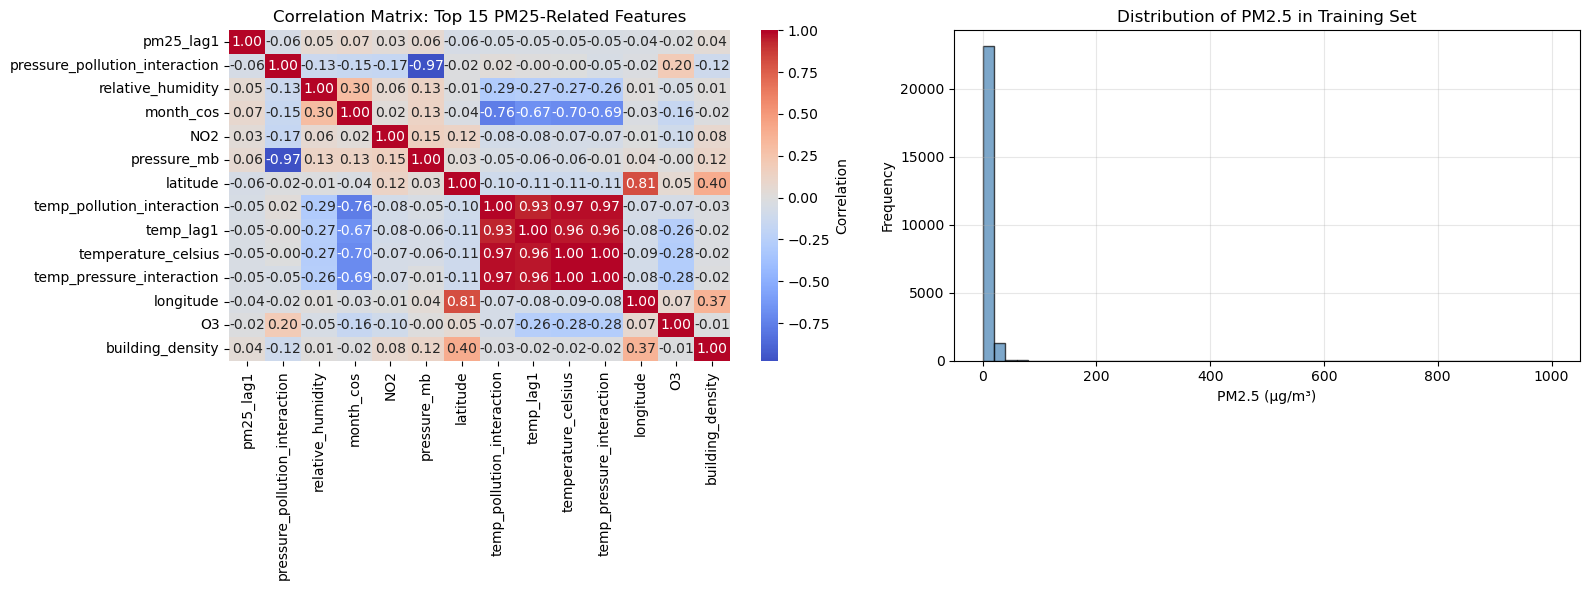

✓ Target variable statistics:
count    24543.000000
mean         9.206177
std         16.792702
min          0.000000
25%          4.127178
50%          7.454545
75%         11.833333
max       1000.000000
Name: pm25, dtype: float64


In [94]:
# Visualize correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top correlations with target (exclude pm25 itself)
top_features = [f for f in target_corr.abs().nlargest(15).index.tolist() if f != 'pm25'][:15]
subset_corr = X_train[top_features].corr()

sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix: Top 15 PM25-Related Features')

# Distribution of target variable
axes[1].hist(y_train, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].set_xlabel('PM2.5 (μg/m³)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of PM2.5 in Training Set')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Target variable statistics:")
print(y_train.describe())

## Decision: Keep All 31 Features

**Why?** Tree-based models (RF, XGBoost, LightGBM) handle correlated features well. Each feature captures distinct domain information. No extreme redundancy detected. Standard practice: benchmark full-feature models first, optimize later if needed.

---
# PHASE 7: Quality Assurance 

In [95]:
print("="*80)
print("FINAL QUALITY ASSURANCE & SUMMARY")
print("="*80)

print("\n1. DATA INTEGRITY CHECKS:")
print(f"   ✓ No NaN values in X_train: {X_train.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in X_val: {X_val.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in X_test: {X_test.isnull().sum().sum() == 0}")
print(f"   ✓ No NaN values in y_train: {y_train.isnull().sum() == 0}")
print(f"   ✓ No NaN values in y_val: {y_val.isnull().sum() == 0}")
print(f"   ✓ No NaN values in y_test: {y_test.isnull().sum() == 0}")

FINAL QUALITY ASSURANCE & SUMMARY

1. DATA INTEGRITY CHECKS:
   ✓ No NaN values in X_train: True
   ✓ No NaN values in X_val: True
   ✓ No NaN values in X_test: True
   ✓ No NaN values in y_train: True
   ✓ No NaN values in y_val: True
   ✓ No NaN values in y_test: True


In [96]:
print("\n2. FEATURE DIMENSION CHECKS:")
print(f"   ✓ X_train features: {X_train.shape[1]}")
print(f"   ✓ X_val features: {X_val.shape[1]}")
print(f"   ✓ X_test features: {X_test.shape[1]}")
print(f"   ✓ All have same feature count: {X_train.shape[1] == X_val.shape[1] == X_test.shape[1]}")

print("\n3. TEMPORAL ORDERING VERIFICATION:")
print(f"   ✓ Train dates: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"   ✓ Val dates:   {df_val['date'].min()} to {df_val['date'].max()}")
print(f"   ✓ Test dates:  {df_test['date'].min()} to {df_test['date'].max()}")
print(f"   ✓ No overlap between splits: {df_train['date'].max() < df_val['date'].min() and df_val['date'].max() < df_test['date'].min()}")


2. FEATURE DIMENSION CHECKS:
   ✓ X_train features: 36
   ✓ X_val features: 36
   ✓ X_test features: 36
   ✓ All have same feature count: True

3. TEMPORAL ORDERING VERIFICATION:
   ✓ Train dates: 2016-11-25 00:00:00 to 2024-04-21 00:00:00
   ✓ Val dates:   2024-04-22 00:00:00 to 2024-12-06 00:00:00
   ✓ Test dates:  2024-12-07 00:00:00 to 2026-04-06 00:00:00
   ✓ No overlap between splits: True


In [97]:
print("\n4. SCALING VERIFICATION:")
# Check that scaled features have expected properties
print(f"   ✓ StandardScaler features mean ≈ 0: {X_train[scaling_config['standard'][0]].mean():.4f}")
print(f"   ✓ StandardScaler features std ≈ 1: {X_train[scaling_config['standard'][0]].std():.4f}")
print(f"   ✓ RobustScaler applied to pollution features: {len(scaling_config['robust'])} features")
print(f"   ✓ Preserved geographic/categorical features: {len(scaling_config['no_scale'])} features")


4. SCALING VERIFICATION:
   ✓ StandardScaler features mean ≈ 0: 0.0000
   ✓ StandardScaler features std ≈ 1: 1.0000
   ✓ RobustScaler applied to pollution features: 18 features
   ✓ Preserved geographic/categorical features: 14 features


In [98]:
print("\n" + "="*80)
print("PREPROCESSING SUMMARY")
print("="*80)

summary_stats = {
    'Metric': [
        'Total Features',
        'Temporal Features',
        'Engineered Features',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Target: Mean PM25',
        'Target: Std PM25',
        'Target: Min PM25',
        'Target: Max PM25',
        'Missing Values (original)',
        'Missing Values (final)',
        'Scaling: StandardScaler',
        'Scaling: RobustScaler',
        'Files Saved'
    ],
    'Value': [
        len(feature_cols),
        len(temporal_features),
        len(interaction_features),
        len(X_train),
        len(X_val),
        len(X_test),
        f"{y_train.mean():.2f} μg/m³",
        f"{y_train.std():.2f} μg/m³",
        f"{y_train.min():.2f} μg/m³",
        f"{y_train.max():.2f} μg/m³",
        "O3, CO, NO2 (5-6%)",
        "0",
        len(scaling_config['standard']),
        len(scaling_config['robust']),
        "7 files (train/val/test + X/y + scalers)"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("✓ PREPROCESSING PIPELINE COMPLETE")
print("="*80)
print("\nREADY FOR MODEL TRAINING!")
print("\nKey Files Generated in preprocessed_data/:")
print("  1. X_train.csv / y_train.csv - Training features and target")
print("  2. X_val.csv / y_val.csv - Validation features and target")
print("  3. X_test.csv / y_test.csv - Test features and target (HOLD OUT)")
print("  4. standard_scaler.pkl - Fitted scaler for inference")
print("  5. robust_scaler.pkl - Fitted scaler for inference")
print("  6. scaling_config.pkl - Feature grouping configuration")

print("\nNext Steps:")
print("  1. Load X_train, y_train with TimeSeriesSplit CV")
print("  2. Train multiple models (Random Forest, XGBoost, LightGBM, etc.)")
print("  3. Monitor train vs validation error for overfitting detection")
print("  4. Select best model based on validation performance")
print("  5. Evaluate ONLY on X_test, y_test (final assessment)")
print("  6. Save best model + scaling artifacts for production deployment")


PREPROCESSING SUMMARY

                   Metric                                    Value
           Total Features                                       36
        Temporal Features                                       11
      Engineered Features                                        4
         Training Samples                                    24543
       Validation Samples                                     6188
             Test Samples                                    10265
        Target: Mean PM25                               9.21 μg/m³
         Target: Std PM25                              16.79 μg/m³
         Target: Min PM25                               0.00 μg/m³
         Target: Max PM25                            1000.00 μg/m³
Missing Values (original)                       O3, CO, NO2 (5-6%)
   Missing Values (final)                                        0
  Scaling: StandardScaler                                        4
    Scaling: RobustScaler             